<center><span style="font-size:50px;"><b>INITIAL ANALYSIS</b></span></center>

---

---

---

---

<center><span style="font-size:30px;"><b>UPLOADING DATA</b></span></center>

In [1]:
import pandas as pd

# files to upload
files = [   "data/USGS/earthquakes_italy_1990-1995.csv",
            "data/USGS/earthquakes_italy_1995-2000.csv",
            "data/USGS/earthquakes_italy_2000-2005.csv",
            "data/USGS/earthquakes_italy_2005-2010.csv",
            "data/USGS/earthquakes_italy_2010-2020.csv",
            "data/USGS/earthquakes_italy_2020-2026.csv"
        ]

df_list = []

for file in files:
    df_partial = pd.read_csv(file)
    df_list.append(df_partial)

# merge dataframes
df_raw = pd.concat(df_list, ignore_index=True)

Let's observe the obtained dataframe:

In [2]:
print(f"The uploaded dataframe has {len(df_raw):_} rows and {len(df_raw.columns):_} columns.")
memory = df_raw.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:_.2f} MB in RAM memory")

display( pd.concat([df_raw.head(3),df_raw.tail(3)]) )

The uploaded dataframe has 43_470 rows and 22 columns.
It occupies 29.27 MB in RAM memory


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,1990-01-01T03:25:58.270Z,44.3840,7.3120,10.000,1.6,ml,NaN,NaN,NaN,0.00,...,2014-11-07T00:45:26.432Z,"2 km SSW of Monterosso Grana, Italy",earthquake,NaN,NaN,NaN,NaN,reviewed,us,gen
1,1990-01-01T06:34:04.000Z,41.7140,19.4310,10.000,3.3,ml,NaN,NaN,NaN,1.20,...,2014-11-07T00:45:26.440Z,"17 km SW of Shëngjin, Albania",earthquake,NaN,NaN,NaN,NaN,reviewed,us,sko
2,1990-01-01T16:38:24.410Z,46.8010,9.7380,5.000,3.1,ml,NaN,NaN,NaN,1.30,...,2014-11-07T00:45:26.932Z,"5 km ENE of Arosa, Switzerland",earthquake,NaN,NaN,NaN,NaN,reviewed,us,grf
43467,2026-04-03T06:51:16.193Z,39.5749,20.6416,10.000,4.3,mb,48.0,46.0,1.426,0.84,...,2026-04-03T14:31:17.520Z,"16 km NE of Paramythiá, Greece",earthquake,5.56,1.884,0.133,16.0,reviewed,us,us
43468,2026-04-04T16:24:22.657Z,39.6618,20.5776,23.533,4.1,mb,44.0,46.0,1.506,0.91,...,2026-04-04T18:23:35.040Z,"13 km WSW of Rodotópi, Greece",earthquake,4.21,5.355,0.093,34.0,reviewed,us,us
43469,2026-04-06T04:20:50.717Z,39.7119,20.7070,10.000,4.6,mwr,35.0,62.0,1.425,0.99,...,2026-04-06T04:36:12.040Z,"1 km WNW of Rodotópi, Greece",earthquake,3.50,1.906,0.053,34.0,reviewed,us,us


In [3]:
print("\nCOLUMNS:")
print(df_raw.columns)


COLUMNS:
Index(['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst',
       'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type',
       'horizontalError', 'depthError', 'magError', 'magNst', 'status',
       'locationSource', 'magSource'],
      dtype='object')


Meaning of the less obvious comlumns (the majority are useless to us):
* depth: Depth of the earthquake in kilometers (km).
* mag: Magnitude of the earthquake
* magType: method used to calculate the earthquake’s magnitude. ml = Local Magnitude (aka Richter scale). mw / mww / mwc / mwb / mwr = Moment Magnitude variants, more accurate for larger earthquakes (modern standard)
* nst: Number of seismic stations that reported the event.
* gap: Largest azimuthal gap in station coverage (degrees).
* dmin: Distance to the nearest station (in degrees).
* rms: Root mean square of the travel time residuals (in seconds).
* net: Network that detected the event (e.g., us, ci, hv). It identifies the organization or seismic network responsible.
* id: The unique identifier for the earthquake event. It’s usually a string combining the net code and a unique event code.
* updated: Time the event information was last updated.
* place: Human-readable location (e.g., "10km SE of Town X").
* type: Type of seismic event (earthquake, quarry blast, etc.). But I only downloaded earthquakes so this column should be useless.
* horizontalError: Horizontal location error (in km or m).
* depthError: Error estimate for the depth (in km).
* magError: Error estimate for the magnitude.
* magNst: Number of stations used for magnitude calculation.
* status: Review status of the event (reviewed, automatic). It means whether the data has been automatically generated or manually reviewed by a seismologist.
* locationSource: Agency that determined the location.
* magSource: Agency that determined the magnitude.

---

---

---

---

<center><span style="font-size:30px;"><b>FILTERING DATA</b></span></center>

Let's keep only earthquakes happened in Italy and only useful columns:

In [22]:
# Keep only the useful columns
df_filtered = df_raw#[['time', 'latitude', 'longitude', 'depth', 'mag', 'place']]

# Filter rows where 'place' contains the word "Italy" (case-insensitive)
mask = df_filtered['place'].str.contains("Italy", case=False, na=False)

# Apply the filter to the reduced dataframe
df = df_filtered[mask].reset_index(drop=True)

In [5]:
print(f"The uploaded dataframe has {len(df):_} rows and {len(df.columns):_} columns.")
memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:_.2f} MB in RAM memory")

display( pd.concat([df.head(5),df.tail(5)]) )

The uploaded dataframe has 19_264 rows and 22 columns.
It occupies 12.86 MB in RAM memory


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,1990-01-01T03:25:58.270Z,44.3840,7.3120,10.000,1.6,ml,NaN,NaN,NaN,0.00,...,2014-11-07T00:45:26.432Z,"2 km SSW of Monterosso Grana, Italy",earthquake,NaN,NaN,NaN,NaN,reviewed,us,gen
1,1990-01-01T18:19:32.100Z,45.0370,7.3020,10.000,2.3,ml,NaN,NaN,NaN,0.70,...,2014-11-07T00:45:27.141Z,"1 km S of Coazze, Italy",earthquake,NaN,NaN,NaN,NaN,reviewed,us,gen
2,1990-01-01T18:46:01.200Z,44.4150,8.1120,10.000,1.7,ml,NaN,NaN,NaN,0.50,...,2014-11-07T00:45:27.156Z,"2 km WSW of Camerana, Italy",earthquake,NaN,NaN,NaN,NaN,reviewed,us,gen
3,1990-01-01T19:50:17.150Z,44.3220,7.4520,10.000,1.7,ml,NaN,NaN,NaN,0.20,...,2014-11-07T00:45:27.173Z,"2 km WNW of Roccavione, Italy",earthquake,NaN,NaN,NaN,NaN,reviewed,us,gen
4,1990-01-02T00:15:03.150Z,44.3660,7.1730,10.000,1.6,ml,NaN,NaN,NaN,0.00,...,2014-11-07T00:45:27.208Z,"5 km SSW of Campomolino, Italy",earthquake,NaN,NaN,NaN,NaN,reviewed,us,gen
19259,2026-03-13T08:54:59.086Z,40.7276,15.4985,10.000,2.2,ml,5.0,133.0,0.768,1.16,...,2026-03-16T13:53:34.873Z,"3 km SSE of Muro Lucano, Italy",earthquake,2.11,1.799,0.115,10.0,reviewed,us,us
19260,2026-03-21T01:46:05.619Z,38.4955,14.3678,10.000,5.2,mb,94.0,59.0,1.870,0.74,...,2026-04-02T21:48:54.055Z,"40 km W of Leni, Italy",earthquake,4.42,1.840,0.037,247.0,reviewed,us,us
19261,2026-03-21T01:49:10.169Z,38.5003,14.3653,10.000,4.3,mb,48.0,85.0,1.868,1.28,...,2026-04-02T22:04:29.040Z,"40 km W of Leni, Italy",earthquake,6.91,1.880,0.102,27.0,reviewed,us,us
19262,2026-03-21T18:04:58.392Z,38.0790,14.5935,60.858,4.1,mb,41.0,152.0,2.135,0.95,...,2026-03-21T18:37:55.040Z,"2 km NNE of Acquedolci, Italy",earthquake,7.38,10.864,0.136,15.0,reviewed,us,us
19263,2026-03-26T08:40:30.776Z,44.0376,10.9974,72.371,4.2,mb,26.0,104.0,0.313,1.11,...,2026-03-26T16:31:42.638Z,"6 km WNW of Cantagallo, Italy",earthquake,7.37,4.465,0.131,16.0,reviewed,us,us


In [8]:
df['magType'].value_counts()

magType
ml      12894
md       5200
mb        932
mwr       112
m          49
mwc        33
mww        27
mw          9
mwb         4
ms          3
mblg        1
Name: count, dtype: int64

# PLOTS

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for the plots in the notebook
sns.set_theme(style="whitegrid")
%matplotlib inline

# Assuming your dataframe is named 'df'
# Convert the 'time' column to datetime format (handles various formats automatically)
df['time'] = pd.to_datetime(df['time'], utc=True)

# Create a new 'year' column for our grouped analyses
df['year'] = df['time'].dt.year

# Take a quick look to ensure everything is correct
display(df.tail())

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,year
19259,2026-03-13 08:54:59.086000+00:00,40.7276,15.4985,10.000,2.2,ml,5.0,133.0,0.768,1.16,...,"3 km SSE of Muro Lucano, Italy",earthquake,2.11,1.799,0.115,10.0,reviewed,us,us,2026
19260,2026-03-21 01:46:05.619000+00:00,38.4955,14.3678,10.000,5.2,mb,94.0,59.0,1.870,0.74,...,"40 km W of Leni, Italy",earthquake,4.42,1.840,0.037,247.0,reviewed,us,us,2026
19261,2026-03-21 01:49:10.169000+00:00,38.5003,14.3653,10.000,4.3,mb,48.0,85.0,1.868,1.28,...,"40 km W of Leni, Italy",earthquake,6.91,1.880,0.102,27.0,reviewed,us,us,2026
19262,2026-03-21 18:04:58.392000+00:00,38.0790,14.5935,60.858,4.1,mb,41.0,152.0,2.135,0.95,...,"2 km NNE of Acquedolci, Italy",earthquake,7.38,10.864,0.136,15.0,reviewed,us,us,2026
19263,2026-03-26 08:40:30.776000+00:00,44.0376,10.9974,72.371,4.2,mb,26.0,104.0,0.313,1.11,...,"6 km WNW of Cantagallo, Italy",earthquake,7.37,4.465,0.131,16.0,reviewed,us,us,2026


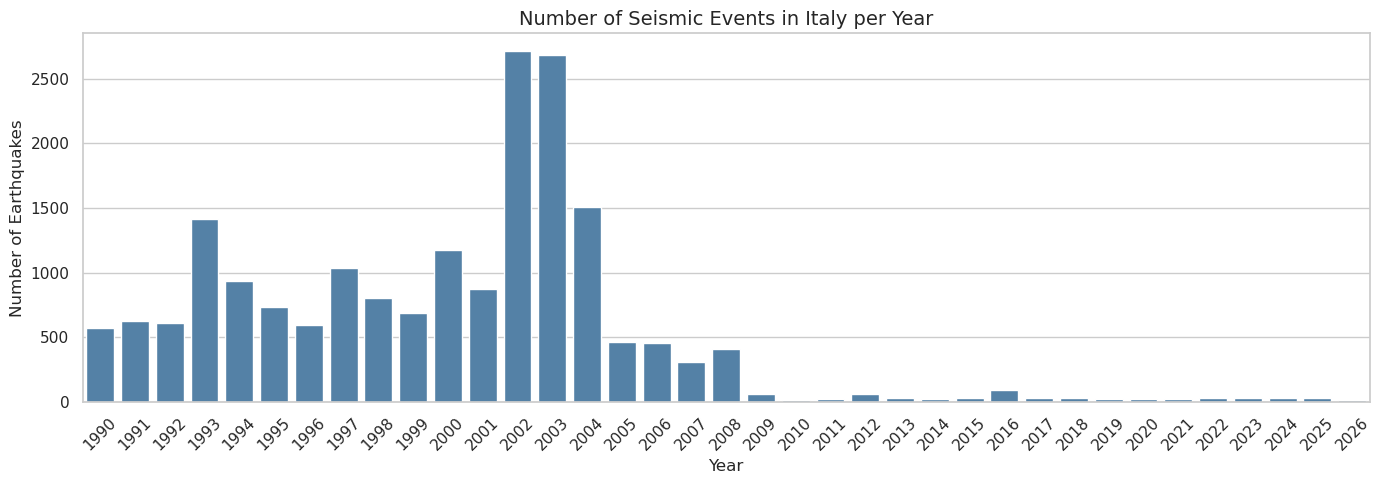

In [24]:
plt.figure(figsize=(14, 5))
sns.countplot(data=df, x='year', color='steelblue')
plt.xticks(rotation=45)
plt.title('Number of Seismic Events in Italy per Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Earthquakes')
plt.tight_layout()
plt.show()

/tmp/ipykernel_25541/1864189479.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='year', y='mag', palette='viridis')


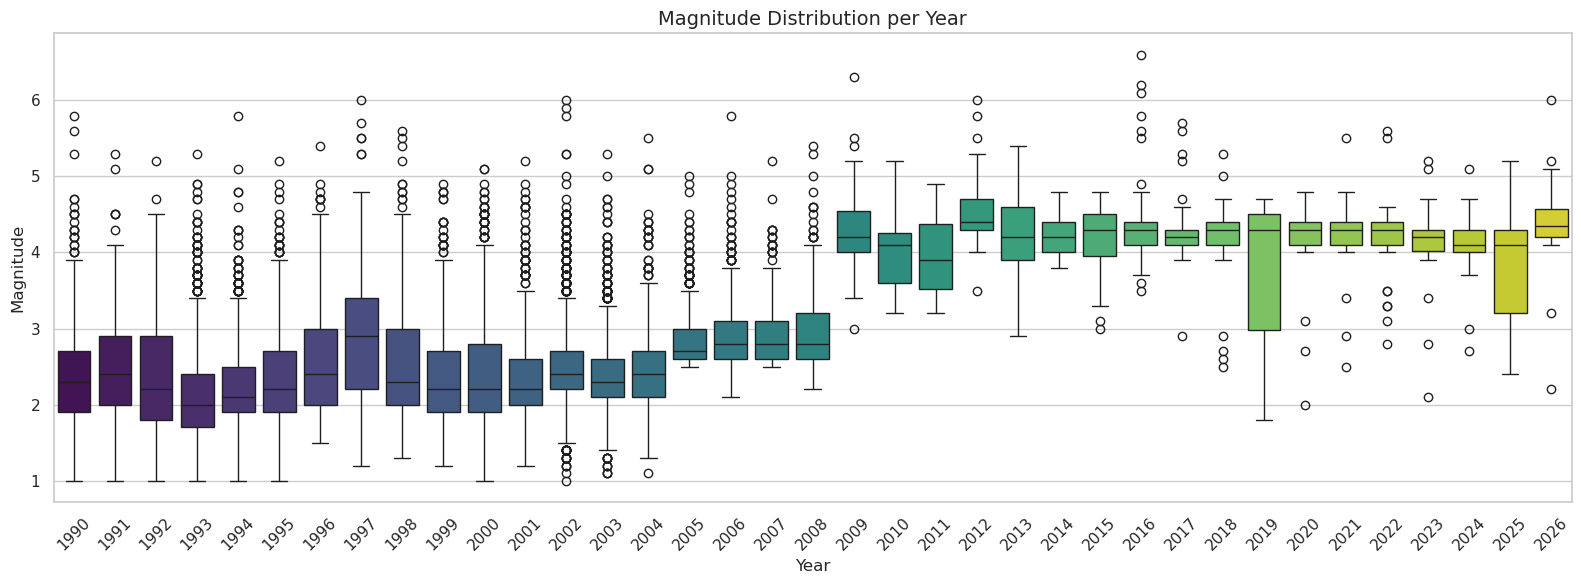

In [25]:
plt.figure(figsize=(16, 6))
sns.boxplot(data=df, x='year', y='mag', palette='viridis')
plt.xticks(rotation=45)
plt.title('Magnitude Distribution per Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Magnitude')
plt.tight_layout()
plt.show()

/tmp/ipykernel_25541/3735775173.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='year', y='depth', palette='magma')


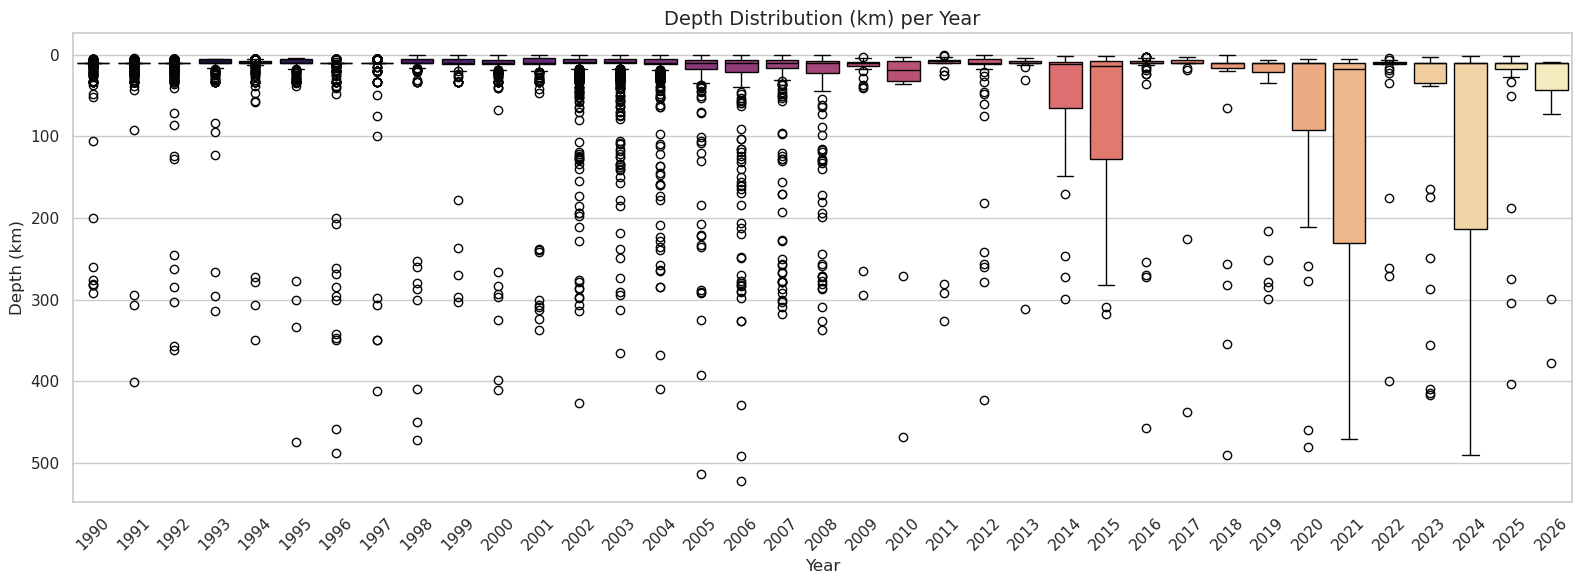

In [26]:
plt.figure(figsize=(16, 6))
sns.boxplot(data=df, x='year', y='depth', palette='magma')

# Invert the Y-axis to visually simulate underground depth (0 at the top)
plt.gca().invert_yaxis() 

plt.xticks(rotation=45)
plt.title('Depth Distribution (km) per Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Depth (km)')
plt.tight_layout()
plt.show()

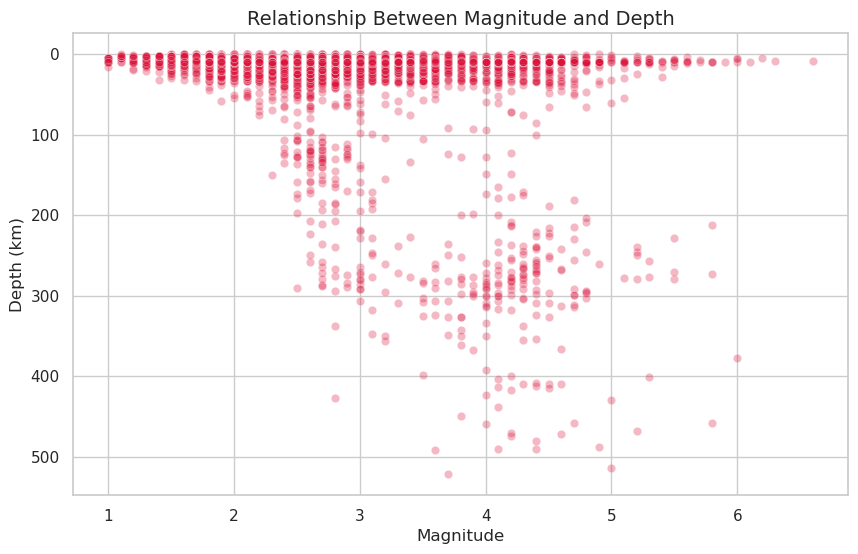

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='mag', y='depth', alpha=0.3, color='crimson')

# Invert the Y-axis here as well for consistency
plt.gca().invert_yaxis()

plt.title('Relationship Between Magnitude and Depth', fontsize=14)
plt.xlabel('Magnitude')
plt.ylabel('Depth (km)')
plt.show()